# Neural GPD

Covariate-varying GPD scale for left-tail GARCH residual exceedances.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import genpareto
from scipy.optimize import minimize

sns.set(style="whitegrid")

try:
    import torch
    import torch.nn as nn
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False

print(f"HAS_TORCH = {HAS_TORCH}" + (f" (torch {torch.__version__})" if HAS_TORCH else " -- falling back to scipy.optimize"))

SEEDS = [0, 1, 2, 3, 4]
print(f"Seeds for the 5-run guardrail: {SEEDS}")


HAS_TORCH = True (torch 2.6.0)
Seeds for the 5-run guardrail: [0, 1, 2, 3, 4]


## Shape Parameter

`xi` is held constant; only the GPD scale varies with covariates.


## Data and Covariates


In [2]:
# Tolerant column matching: stooq exports have varied in case before.
raw = pd.read_csv('spy.csv')
colmap = {c.lower(): c for c in raw.columns}
assert 'date' in colmap and 'close' in colmap, (
    f"Could not find date/close columns in spy.csv -- got columns: {list(raw.columns)}")
price = raw.rename(columns={colmap['date']: 'Date', colmap['close']: 'Close'})[['Date', 'Close']].copy()
price['Date'] = pd.to_datetime(price['Date'])
price = price.sort_values('Date').reset_index(drop=True)

price['Return'] = np.log(price['Close'] / price['Close'].shift(1))
price.head()


,Date,Close,Return
0,1985-01-02,165.369995,NaN
1,1985-01-03,164.570007,-0.004849
2,1985-01-04,163.679993,-0.005423
3,1985-01-07,164.240005,0.003416
4,1985-01-08,163.990005,-0.001523


In [3]:
# ---------------------------------------------------------------------------
# rv_5 / rv_22: rolling realized volatility of returns, LAGGED by one day so
# the covariate available "as of the close of day t-1" is what's used to
# predict day t's tail behavior. The .shift(1) is mandatory -- getting this
# wrong (using rolling() directly on same-day returns) is the single most
# common way this class of project leaks the future into the covariates and
# produces results that don't replicate.
# ---------------------------------------------------------------------------

lagged_returns_pct = price['Return'].shift(1) * 100
price['rv_5'] = lagged_returns_pct.rolling(5).std()
price['rv_22'] = lagged_returns_pct.rolling(22).std()
price['log_rv_5'] = np.log(price['rv_5'])
price['log_rv_22'] = np.log(price['rv_22'])

# Explicit leakage check: rv_5[t] must be reproducible using ONLY
# returns[t-5:t] (i.e. up to and including day t-1's return, never day t's).
# This directly tests the alignment rather than trusting rolling()+shift().
rng_check = np.random.default_rng(0)
check_idx = [50, 500, 5000, len(price) - 50] + list(rng_check.integers(60, len(price) - 60, size=5))
for i in check_idx:
    manual_rv5 = price['Return'].iloc[i - 5:i].std(ddof=1) * 100
    assert np.isclose(price['rv_5'].iloc[i], manual_rv5, equal_nan=True), (
        f"LEAKAGE CHECK FAILED at row {i}: rv_5={price['rv_5'].iloc[i]}, "
        f"manual (returns[i-5:i] only)={manual_rv5}")
print(f"Leakage check passed at {len(check_idx)} spot-checked rows: "
      f"rv_5[t] is reproducible from returns[t-5:t] only (strictly before day t).")


Leakage check passed at 9 spot-checked rows: rv_5[t] is reproducible from returns[t-5:t] only (strictly before day t).


In [4]:
resid = pd.read_csv('standardized_residuals.csv', parse_dates=['Date'])
resid = resid.rename(columns={'t Standardized Residuals': 'Residual'})

HAS_GARCH_VOL = 'Conditional Volatility' in resid.columns
if HAS_GARCH_VOL:
    assert (resid['Conditional Volatility'].dropna() > 0).all(), "non-positive conditional volatility found"
    resid['log_sigma_garch'] = np.log(resid['Conditional Volatility'])
    print("01_time_series_modeling.ipynb exported conditional volatility -- using log_sigma_garch as a third covariate.")
else:
    print("No 'Conditional Volatility' column in standardized_residuals.csv -- proceeding with 2 covariates (log_rv_5, log_rv_22) only.")

resid[['Date', 'Residual'] + (['log_sigma_garch'] if HAS_GARCH_VOL else [])].head()


01_time_series_modeling.ipynb exported conditional volatility -- using log_sigma_garch as a third covariate.


,Date,Residual,log_sigma_garch
0,1985-01-03,-0.711809,-4.842590
1,1985-01-04,-0.797717,-4.859263
2,1985-01-07,0.345256,-4.869313
3,1985-01-08,-0.308668,-4.904688
4,1985-01-09,0.904156,-4.940473


In [5]:
COVARIATE_COLS = ['log_rv_5', 'log_rv_22'] + (['log_sigma_garch'] if HAS_GARCH_VOL else [])

price_clean = price.dropna(subset=['log_rv_5', 'log_rv_22']).copy()
resid_clean = resid.dropna(subset=['Residual'] + (['log_sigma_garch'] if HAS_GARCH_VOL else [])).copy()

merged = pd.merge(
    price_clean[['Date'] + ['log_rv_5', 'log_rv_22']],
    resid_clean[['Date', 'Residual'] + (['log_sigma_garch'] if HAS_GARCH_VOL else [])],
    on='Date', how='inner',
)

print(f"price rows (after dropping rolling-window warmup NaNs): {len(price_clean)}")
print(f"residual rows (after dropping NaNs): {len(resid_clean)}")
print(f"merged rows (inner join on Date): {len(merged)}")

expected_min = min(len(price_clean), len(resid_clean))
loss = expected_min - len(merged)
if loss > 5:
    print(f"WARNING: merge lost {loss} rows beyond simple date-range mismatch -- check for duplicate or misaligned dates.")
else:
    print(f"Row loss from the join ({loss}) is consistent with date-range differences between the two files, not misalignment.")

merged = merged.dropna(subset=COVARIATE_COLS + ['Residual']).sort_values('Date').reset_index(drop=True)
print(f"final modeling rows after dropping any remaining NaNs: {len(merged)}")
merged.head()


price rows (after dropping rolling-window warmup NaNs): 10131
residual rows (after dropping NaNs): 10153
merged rows (inner join on Date): 10131
Row loss from the join (0) is consistent with date-range differences between the two files, not misalignment.
final modeling rows after dropping any remaining NaNs: 10131


,Date,log_rv_5,log_rv_22,Residual,log_sigma_garch
0,1985-02-04,-0.586653,-0.260970,1.117732,-4.842224
1,1985-02-05,-0.423642,-0.278259,0.084145,-4.823920
2,1985-02-06,-0.620700,-0.315592,-0.228651,-4.865969
3,1985-02-07,-0.597140,-0.303246,0.932414,-4.904818
4,1985-02-08,-0.472117,-0.314676,0.170819,-4.902821


## Split and Threshold

Train is before 2018-01-01; test is 2018 onward. Threshold is fit on train only.


In [6]:
SPLIT_DATE = pd.Timestamp('2018-01-01')
train_df = merged[merged['Date'] < SPLIT_DATE].reset_index(drop=True)
test_df = merged[merged['Date'] >= SPLIT_DATE].reset_index(drop=True)
print(f"train rows: {len(train_df)} ({train_df['Date'].min().date()} to {train_df['Date'].max().date()})")
print(f"test rows:  {len(test_df)} ({test_df['Date'].min().date()} to {test_df['Date'].max().date()})")

u = train_df['Residual'].quantile(0.064)
train_exceed_mask = train_df['Residual'] < u
test_exceed_mask = test_df['Residual'] < u

n_train_exceed = int(train_exceed_mask.sum())
n_test_exceed = int(test_exceed_mask.sum())
test_exceed_rate = n_test_exceed / len(test_df)

print(f"\nThreshold u (frozen, from TRAIN only) = {u:.4f}")
print(f"train exceedances: {n_train_exceed} of {len(train_df)} ({n_train_exceed/len(train_df):.4f})")
print(f"test exceedances:  {n_test_exceed} of {len(test_df)} (realised rate {test_exceed_rate:.4f})")

if n_test_exceed < 100:
    print(f"\nWARNING: only {n_test_exceed} test exceedances -- out-of-sample model "
          f"comparisons below will be noisy. Continuing anyway, as requested.")


train rows: 8296 (1985-02-04 to 2017-12-29)
test rows:  1835 (2018-01-02 to 2025-04-21)

Threshold u (frozen, from TRAIN only) = -1.5438
train exceedances: 531 of 8296 (0.0640)
test exceedances:  131 of 1835 (realised rate 0.0714)


## Constant-GPD Baseline


In [7]:
def gpd_neg_log_pdf(y, xi, sigma, eps=1e-9):
    """GPD negative log-density (loc=0), y > 0. Written ONCE and reused for
    the baseline fit's test evaluation, the neural model's training loss
    (torch mirror below), and the neural model's test evaluation, so no
    model gets a different, hand-tuned notion of likelihood."""
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    z = xi * y / sigma
    one_plus_z = np.clip(1.0 + z, eps, None)
    return np.log(sigma) + (1.0 + 1.0 / xi) * np.log(one_plus_z)


def gpd_cdf(y, xi, sigma, eps=1e-9):
    """GPD CDF (loc=0), for the probability-integral-transform check below."""
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    z = xi * y / sigma
    one_plus_z = np.clip(1.0 + z, eps, None)
    return 1.0 - one_plus_z ** (-1.0 / xi)


# Sanity check: our hand-written GPD matches scipy's own reference
# implementation, before we rely on it for anything below.
_y_check = np.array([0.1, 0.5, 1.0, 2.0, 5.0])
_ref_nll = -genpareto.logpdf(_y_check, c=0.15, loc=0, scale=0.6)
_our_nll = gpd_neg_log_pdf(_y_check, xi=0.15, sigma=0.6)
assert np.allclose(_ref_nll, _our_nll), "hand-written GPD NLL does not match scipy.stats.genpareto"
_ref_cdf = genpareto.cdf(_y_check, c=0.15, loc=0, scale=0.6)
_our_cdf = gpd_cdf(_y_check, xi=0.15, sigma=0.6)
assert np.allclose(_ref_cdf, _our_cdf), "hand-written GPD CDF does not match scipy.stats.genpareto"
print("gpd_neg_log_pdf / gpd_cdf verified against scipy.stats.genpareto.")


gpd_neg_log_pdf / gpd_cdf verified against scipy.stats.genpareto.


In [8]:
train_excess = (u - train_df.loc[train_exceed_mask, 'Residual']).to_numpy()
test_excess = (u - test_df.loc[test_exceed_mask, 'Residual']).to_numpy()
assert (train_excess > 0).all() and (test_excess > 0).all(), "excess must be strictly positive under the u - z convention"

# Same genpareto.fit(..., floc=0) MLE call used in 02_evt_threshold_analysis.ipynb.
xi_base, loc_base, sigma_base = genpareto.fit(train_excess, floc=0)
assert loc_base == 0

baseline_test_nll = gpd_neg_log_pdf(test_excess, xi_base, sigma_base).mean()

print(f"Baseline GPD fit (train exceedances, n={len(train_excess)}):")
print(f"  xi_base    = {xi_base:.4f}")
print(f"  sigma_base = {sigma_base:.4f}")
print(f"  mean test NLL per exceedance = {baseline_test_nll:.4f}  (n_test_exceed={len(test_excess)})")
print()
print("Every neural-model number below is compared against this baseline.")


Baseline GPD fit (train exceedances, n=531):
  xi_base    = 0.1508
  sigma_base = 0.5849
  mean test NLL per exceedance = 0.7992  (n_test_exceed=131)

Every neural-model number below is compared against this baseline.


## Neural Scale Model

One hidden layer predicts the GPD scale for exceedances.


In [9]:
# Standardize on TRAIN only.
covariate_mean = train_df[COVARIATE_COLS].mean()
covariate_std = train_df[COVARIATE_COLS].std()

def standardize(df):
    return ((df[COVARIATE_COLS] - covariate_mean) / covariate_std).to_numpy(dtype=np.float64)

# Chronological 85/15 split of TRAIN (by date, not by exceedance) for early
# stopping. The frozen threshold u (fit on ALL of train) is then applied
# separately within each chronological slice.
n_train = len(train_df)
fit_cutoff = int(n_train * 0.85)
train_fit_df = train_df.iloc[:fit_cutoff]
train_val_df = train_df.iloc[fit_cutoff:]

fit_exceed_mask = train_fit_df['Residual'] < u
val_exceed_mask = train_val_df['Residual'] < u

X_fit = standardize(train_fit_df)[fit_exceed_mask.to_numpy()]
y_fit = (u - train_fit_df.loc[fit_exceed_mask, 'Residual']).to_numpy()
X_val = standardize(train_val_df)[val_exceed_mask.to_numpy()]
y_val = (u - train_val_df.loc[val_exceed_mask, 'Residual']).to_numpy()
X_test = standardize(test_df)[test_exceed_mask.to_numpy()]  # covariates at TEST EXCEEDANCE rows only, matching y_test
y_test = test_excess

print(f"train-fit period: {train_fit_df['Date'].min().date()} to {train_fit_df['Date'].max().date()}, "
      f"{len(train_fit_df)} rows, {len(y_fit)} exceedances")
print(f"train-val period: {train_val_df['Date'].min().date()} to {train_val_df['Date'].max().date()}, "
      f"{len(train_val_df)} rows, {len(y_val)} exceedances")
print(f"test exceedances used for evaluation: {len(y_test)}")


train-fit period: 1985-02-04 to 2013-01-22, 7051 rows, 459 exceedances
train-val period: 2013-01-23 to 2017-12-29, 1245 rows, 72 exceedances
test exceedances used for evaluation: 131


In [10]:
N_FEATURES = len(COVARIATE_COLS)
HIDDEN = 8
MAX_EPOCHS = 3000
PATIENCE = 150
LR = 1e-3

n_net_params = N_FEATURES * HIDDEN + HIDDEN + HIDDEN + 1  # fc1 weight+bias, fc2 weight+bias
n_total_params = n_net_params + 1  # + xi
param_ratio = n_total_params / len(y_fit)
print(f"Neural model parameters: {n_net_params} (network) + 1 (xi) = {n_total_params}")
print(f"Training exceedances used for gradient updates (train-fit split): {len(y_fit)}")
print(f"parameter-count / training-exceedance-count ratio = {param_ratio:.3f}")
if param_ratio > 0.10:
    print("FLAG: parameter count exceeds ~10% of the training exceedance count -- see the overfitting-risk note below.")
else:
    print("Parameter count is within the ~10% guideline relative to training exceedances.")


Neural model parameters: 41 (network) + 1 (xi) = 42
Training exceedances used for gradient updates (train-fit split): 459
parameter-count / training-exceedance-count ratio = 0.092
Parameter count is within the ~10% guideline relative to training exceedances.


In [11]:
def gpd_neg_log_pdf_torch(y, xi, sigma, eps=1e-6):
    """Torch mirror of gpd_neg_log_pdf above -- identical formula, needed
    only for autodiff. Not a different likelihood."""
    z = xi * y / sigma
    one_plus_z = torch.clamp(1.0 + z, min=eps)
    return torch.log(sigma) + (1.0 + 1.0 / xi) * torch.log(one_plus_z)


class SigmaNet(nn.Module):
    def __init__(self, n_features, hidden, sigma_init):
        super().__init__()
        self.fc1 = nn.Linear(n_features, hidden)
        self.fc2 = nn.Linear(hidden, 1)
        # Start sigma(x) ~= sigma_init for every x: zero the final layer's
        # weights (so covariate-dependence starts at exactly zero) and set
        # its bias to softplus^{-1}(sigma_init).
        nn.init.zeros_(self.fc2.weight)
        with torch.no_grad():
            inv_softplus_init = float(np.log(np.expm1(sigma_init)))
            self.fc2.bias.fill_(inv_softplus_init)

    def forward(self, x):
        h = torch.tanh(self.fc1(x))
        raw = self.fc2(h).squeeze(-1)
        return nn.functional.softplus(raw)


def softplus_np(x):
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0)


def fit_neural_model_scipy_fallback(seed, X_fit, y_fit, X_val, y_val, n_features, hidden, sigma_init, xi_init, max_iter=2000):
    """Fallback path if torch is unavailable: hand-written 2-layer forward
    pass, optimized with scipy.optimize.minimize (L-BFGS-B), with a
    callback-based crude early stopping against the validation set."""
    rng = np.random.default_rng(seed)
    w1 = rng.normal(0, 0.1, (n_features, hidden))
    b1 = np.zeros(hidden)
    w2 = np.zeros(hidden)  # zero final-layer weights: sigma(x) starts flat
    b2 = np.array([np.log(np.expm1(sigma_init))])
    theta0 = np.concatenate([w1.ravel(), b1, w2, b2, [xi_init]])

    def unpack(theta):
        i = 0
        W1 = theta[i:i + n_features * hidden].reshape(n_features, hidden); i += n_features * hidden
        b1_ = theta[i:i + hidden]; i += hidden
        W2 = theta[i:i + hidden]; i += hidden
        b2_ = theta[i]; i += 1
        xi_ = theta[i]
        return W1, b1_, W2, b2_, xi_

    def forward_sigma(theta, X):
        W1, b1_, W2, b2_, xi_ = unpack(theta)
        h = np.tanh(X @ W1 + b1_)
        raw = h @ W2 + b2_
        return softplus_np(raw), xi_

    def objective(theta):
        sigma_fit, xi_ = forward_sigma(theta, X_fit)
        return gpd_neg_log_pdf(y_fit, xi_, sigma_fit).mean()

    best = {"val": np.inf, "theta": theta0.copy()}

    def callback(theta):
        sigma_val, xi_ = forward_sigma(theta, X_val)
        val = gpd_neg_log_pdf(y_val, xi_, sigma_val).mean()
        if val < best["val"]:
            best["val"] = val
            best["theta"] = theta.copy()

    minimize(objective, theta0, method="L-BFGS-B", callback=callback, options={"maxiter": max_iter})
    theta_final = best["theta"]
    _, _, _, _, xi_final = unpack(theta_final)

    class ScipyModelWrapper:
        def predict_sigma(self, X):
            sigma, _ = forward_sigma(theta_final, X)
            return sigma

    return ScipyModelWrapper(), float(xi_final), best["val"]


In [12]:
def run_one_seed_torch(seed, X_fit, y_fit, X_val, y_val, X_test, y_test,
                        n_features, hidden, sigma_init, xi_init,
                        max_epochs=MAX_EPOCHS, patience=PATIENCE, lr=LR):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = SigmaNet(n_features, hidden, sigma_init)
    xi_param = nn.Parameter(torch.tensor(float(xi_init)))
    optimizer = torch.optim.Adam(list(model.parameters()) + [xi_param], lr=lr)

    Xf = torch.tensor(X_fit, dtype=torch.float32)
    yf = torch.tensor(y_fit, dtype=torch.float32)
    Xv = torch.tensor(X_val, dtype=torch.float32)
    yv = torch.tensor(y_val, dtype=torch.float32)

    best_val = np.inf
    best_state = None
    best_xi = xi_init
    best_epoch = 0
    epochs_since_improve = 0
    val_history = []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        sigma_fit = model(Xf)
        loss = gpd_neg_log_pdf_torch(yf, xi_param, sigma_fit).mean()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            sigma_val = model(Xv)
            val_loss = gpd_neg_log_pdf_torch(yv, xi_param, sigma_val).mean().item()
        val_history.append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_xi = xi_param.item()
            best_epoch = epoch
            epochs_since_improve = 0
        else:
            epochs_since_improve += 1
            if epochs_since_improve >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        sigma_test = model(torch.tensor(X_test, dtype=torch.float32)).numpy()

    test_nll = gpd_neg_log_pdf(y_test, best_xi, sigma_test).mean()

    return dict(seed=seed, model=model, xi=best_xi, best_val_nll=best_val,
                test_nll=test_nll, sigma_test=sigma_test, best_epoch=best_epoch,
                n_epochs_run=len(val_history), val_history=val_history)


def run_one_seed(seed, *args, **kwargs):
    if HAS_TORCH:
        return run_one_seed_torch(seed, *args, **kwargs)
    else:
        X_fit, y_fit, X_val, y_val, X_test, y_test = args[:6]
        model, xi_final, best_val = fit_neural_model_scipy_fallback(
            seed, X_fit, y_fit, X_val, y_val, N_FEATURES, HIDDEN, sigma_base, xi_base)
        sigma_test = model.predict_sigma(X_test)
        test_nll = gpd_neg_log_pdf(y_test, xi_final, sigma_test).mean()
        return dict(seed=seed, model=model, xi=xi_final, best_val_nll=best_val,
                    test_nll=test_nll, sigma_test=sigma_test, best_epoch=None,
                    n_epochs_run=None, val_history=None)


In [13]:
results = []
for seed in SEEDS:
    r = run_one_seed(seed, X_fit, y_fit, X_val, y_val, X_test, y_test,
                      N_FEATURES, HIDDEN, sigma_base, xi_base)
    results.append(r)
    epoch_info = f"stopped at epoch {r['n_epochs_run']} (best={r['best_epoch']})" if r['n_epochs_run'] is not None else "scipy fallback"
    print(f"seed={seed}: xi={r['xi']:.4f}, test_nll={r['test_nll']:.4f}, {epoch_info}")


seed=0: xi=0.1313, test_nll=0.7928, stopped at epoch 489 (best=338)
seed=1: xi=0.1447, test_nll=0.7903, stopped at epoch 431 (best=280)


seed=2: xi=0.1367, test_nll=0.7908, stopped at epoch 443 (best=292)
seed=3: xi=0.1301, test_nll=0.7929, stopped at epoch 447 (best=296)


seed=4: xi=0.1358, test_nll=0.7912, stopped at epoch 428 (best=277)


## Test Evaluation


In [14]:
seed_nlls = np.array([r['test_nll'] for r in results])
seed_xis = np.array([r['xi'] for r in results])

nll_table = pd.DataFrame({
    'seed': SEEDS,
    'test_nll': seed_nlls,
    'xi': seed_xis,
})
print(nll_table.round(4).to_string(index=False))
print()
print(f"Baseline test NLL (constant sigma, constant xi): {baseline_test_nll:.4f}")
print(f"Neural test NLL:  mean = {seed_nlls.mean():.4f}, std = {seed_nlls.std(ddof=1):.4f}, "
      f"range = [{seed_nlls.min():.4f}, {seed_nlls.max():.4f}]")
print(f"Mean improvement over baseline: {baseline_test_nll - seed_nlls.mean():.4f} "
      f"(positive = neural model better; negative = neural model worse)")
print(f"Seed-to-seed std of test NLL vs. gap to baseline: "
      f"std={seed_nlls.std(ddof=1):.4f} vs gap={abs(baseline_test_nll - seed_nlls.mean()):.4f}")


 seed  test_nll     xi
    0    0.7928 0.1313
    1    0.7903 0.1447
    2    0.7908 0.1367
    3    0.7929 0.1301
    4    0.7912 0.1358

Baseline test NLL (constant sigma, constant xi): 0.7992
Neural test NLL:  mean = 0.7916, std = 0.0012, range = [0.7903, 0.7929]
Mean improvement over baseline: 0.0075 (positive = neural model better; negative = neural model worse)
Seed-to-seed std of test NLL vs. gap to baseline: std=0.0012 vs gap=0.0075


In [15]:
# xi: empirical mean/std across the 5 seeds. This is NOT an asymptotic MLE
# standard error (that would need the Hessian of a network+scalar model,
# which isn't cheaply available here) -- it's the spread induced by
# optimization/initialization randomness across 5 independent fits. With
# only 5 seeds this is itself a rough estimate, but it's an honest way to
# convey how sensitive the fitted xi is to randomness at this sample size.
xi_mean = seed_xis.mean()
xi_se_empirical = seed_xis.std(ddof=1)

xi_from_nu_ref = 0.174   # 1/nu implied by the t-GARCH degrees of freedom (notebook 01)
xi_weissman_ref = 0.146  # constant-sigma Weissman AMSE fit (notebook 02)

print(f"Neural xi: mean = {xi_mean:.4f}, empirical SE (5-seed spread) = {xi_se_empirical:.4f}")
print(f"  range across seeds: [{seed_xis.min():.4f}, {seed_xis.max():.4f}]")
print(f"Baseline (this notebook, constant-sigma) xi: {xi_base:.4f}")
print()
print(f"Reference points:")
print(f"  1/nu (t-GARCH degrees of freedom)         = {xi_from_nu_ref:.4f}")
print(f"  Weissman AMSE constant-sigma fit (NB 02)   = {xi_weissman_ref:.4f}")
print(f"  Neural model (this notebook)               = {xi_mean:.4f} +/- {xi_se_empirical:.4f}")


Neural xi: mean = 0.1357, empirical SE (5-seed spread) = 0.0058
  range across seeds: [0.1301, 0.1447]
Baseline (this notebook, constant-sigma) xi: 0.1508

Reference points:
  1/nu (t-GARCH degrees of freedom)         = 0.1740
  Weissman AMSE constant-sigma fit (NB 02)   = 0.1460
  Neural model (this notebook)               = 0.1357 +/- 0.0058


## Likelihood Comparison

The comparison is descriptive; the models are not treated as a Wilks nested pair.


In [16]:
total_test_loglik_baseline = -gpd_neg_log_pdf(y_test, xi_base, sigma_base).sum()
lr_stats = []
for r in results:
    total_test_loglik_neural = -gpd_neg_log_pdf(y_test, r['xi'], r['sigma_test']).sum()
    lr_stat = 2 * (total_test_loglik_neural - total_test_loglik_baseline)
    lr_stats.append(lr_stat)
    print(f"seed={r['seed']}: 2*(loglik_neural - loglik_baseline) = {lr_stat:.2f}  "
          f"(positive favors the neural model, descriptively -- no p-value)")

print(f"\nmean LR-style statistic across seeds: {np.mean(lr_stats):.2f} (std {np.std(lr_stats, ddof=1):.2f})")


seed=0: 2*(loglik_neural - loglik_baseline) = 1.66  (positive favors the neural model, descriptively -- no p-value)
seed=1: 2*(loglik_neural - loglik_baseline) = 2.32  (positive favors the neural model, descriptively -- no p-value)
seed=2: 2*(loglik_neural - loglik_baseline) = 2.19  (positive favors the neural model, descriptively -- no p-value)
seed=3: 2*(loglik_neural - loglik_baseline) = 1.63  (positive favors the neural model, descriptively -- no p-value)
seed=4: 2*(loglik_neural - loglik_baseline) = 2.08  (positive favors the neural model, descriptively -- no p-value)

mean LR-style statistic across seeds: 1.98 (std 0.31)


Using seed=1 (lowest test NLL among the 5 runs) for the PIT/QQ plot below.


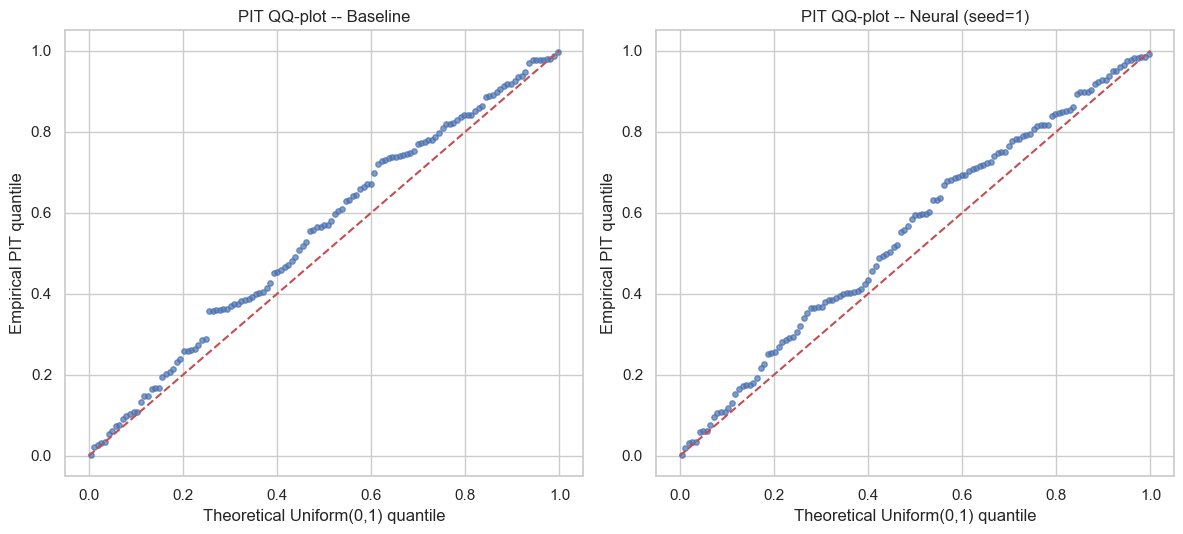

In [17]:
# QQ / probability-integral-transform check: PIT_i = F(y_i; xi, sigma_i)
# should be ~ Uniform(0,1) under a correctly specified model.
best_seed_idx = int(np.argmin(seed_nlls))
best_result = results[best_seed_idx]
print(f"Using seed={best_result['seed']} (lowest test NLL among the 5 runs) for the PIT/QQ plot below.")

pit_baseline = gpd_cdf(y_test, xi_base, sigma_base)
pit_neural = gpd_cdf(y_test, best_result['xi'], best_result['sigma_test'])

fig, axs = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, pit, title in [(axs[0], pit_baseline, 'Baseline'), (axs[1], pit_neural, f"Neural (seed={best_result['seed']})")]:
    sorted_pit = np.sort(pit)
    n = len(sorted_pit)
    theoretical = (np.arange(1, n + 1) - 0.5) / n
    ax.scatter(theoretical, sorted_pit, s=15, alpha=0.7)
    ax.plot([0, 1], [0, 1], 'r--', lw=1.5)
    ax.set(title=f'PIT QQ-plot -- {title}', xlabel='Theoretical Uniform(0,1) quantile', ylabel='Empirical PIT quantile')
plt.tight_layout()
plt.show()


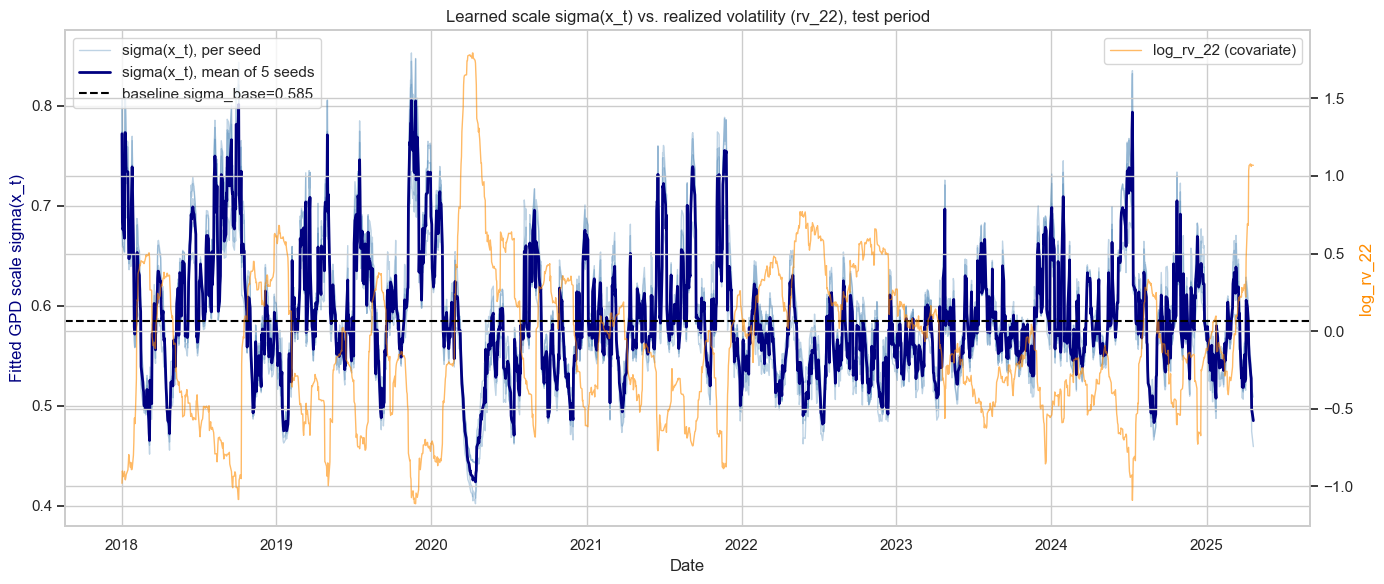

In [18]:
# Fitted sigma(x_t) over the full test period, all 5 seeds, against rv_22.
X_test_full = standardize(test_df)
sigma_paths = []
for r in results:
    if HAS_TORCH:
        with torch.no_grad():
            sp = r['model'](torch.tensor(X_test_full, dtype=torch.float32)).numpy()
    else:
        sp = r['model'].predict_sigma(X_test_full)
    sigma_paths.append(sp)
sigma_paths = np.array(sigma_paths)

fig, ax1 = plt.subplots(figsize=(14, 6))
for i, seed in enumerate(SEEDS):
    ax1.plot(test_df['Date'], sigma_paths[i], color='steelblue', alpha=0.35, lw=1,
             label='sigma(x_t), per seed' if i == 0 else None)
ax1.plot(test_df['Date'], sigma_paths.mean(axis=0), color='navy', lw=2, label='sigma(x_t), mean of 5 seeds')
ax1.axhline(sigma_base, color='black', linestyle='--', lw=1.5, label=f'baseline sigma_base={sigma_base:.3f}')
ax1.set_xlabel('Date')
ax1.set_ylabel('Fitted GPD scale sigma(x_t)', color='navy')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(test_df['Date'], test_df['log_rv_22'], color='darkorange', alpha=0.6, lw=1, label='log_rv_22 (covariate)')
ax2.set_ylabel('log_rv_22', color='darkorange')
ax2.legend(loc='upper right')

plt.title('Learned scale sigma(x_t) vs. realized volatility (rv_22), test period')
plt.tight_layout()
plt.show()


## Overfitting Check

Parameter count is reported against the number of train exceedances.


## Result

The neural GPD gives a modest test-exceedance likelihood improvement, with overfitting risk noted by parameter count.
